<a href="https://colab.research.google.com/github/saikttech/colab-aiagent/blob/main/%D0%94%D0%97_Pro_%D0%A0%D0%B0%D1%81%D0%BF%D0%BE%D0%B7%D0%BD%D0%B0%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B8_%D0%B3%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%80%D0%B5%D1%87%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание Pro

1.   Запишите с помощью микрофона произвольное стихотворение, предварительно скопировав его в переменную text.
2.   Выполните распознавание Вашей речи (можно использовать любой инструмент). Визуализируйте текст распознаный из аудиофайла.
3.   Выполните автоматическое форматирование исходного текста стихотворения для получения лучшей оценки распознавания. Оцените качество распознавания фрагмента с помощью метрики **WER**








# Решение

In [ ]:
# 1: Установка библиотек
!pip install jiwer librosa matplotlib soundfile -q

In [ ]:
# 2: Импорт и получение секретов
import os
import requests
import json
import base64
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Javascript
from google.colab import output, userdata
import jiwer

# Получаем секреты из Colab
try:
    YC_API_KEY = userdata.get('YC_API_KEY_STT')
    YC_FOLDER_ID = userdata.get('YC_FOLDER_ID')
except userdata.SecretNotFoundError:
    raise ValueError("Ошибка: Добавьте секреты YC_API_KEY и YC_FOLDER_ID в настройки Colab Secrets!")

print("✅ Секреты успешно загружены.")

✅ Секреты успешно загружены.


In [ ]:
# 3: Исходный текст и его автоматическое форматирование
# 3.1 Произвольное стихотворение (Ground Truth)
original_text = """
Унылая пора! Очей очарованье!
Приятна мне твоя прощальная краса —
Люблю я пышное природы увяданье,
В багрец и в золото одетые леса.
"""

# 3.2. Функция автоматического форматирования для лучшей оценки (WER)
def format_text_for_wer(text):
    # Приводим к нижнему регистру
    text = text.lower()
    # Заменяем 'ё' на 'е' (STT часто распознает как 'е')
    text = text.replace('ё', 'е')
    # Удаляем знаки препинания и спецсимволы
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    # Убираем множественные пробелы и пробелы по краям
    text = ' '.join(text.split())
    return text

# Сохраняем отформатированный исходный текст в переменную text
text = format_text_for_wer(original_text)
print(f"📝 Исходный текст (отформатирован для WER):\n{text}")

📝 Исходный текст (отформатирован для WER):
унылая пора очей очарованье приятна мне твоя прощальная краса люблю я пышное природы увяданье в багрец и в золото одетые леса


In [ ]:
# 4: audio.mp3
from google.colab import files

print("📁 Загрузите аудиофайл (mp3/wav) с вашим стихотворением:")
uploaded = files.upload()

# Берём первый загруженный файл и переименовываем в audio.mp3
import shutil
for filename in uploaded.keys():
    shutil.move(filename, 'audio.mp3')
    print(f"✅ Файл '{filename}' сохранён как 'audio.mp3'")
    break

📁 Загрузите аудиофайл (mp3/wav) с вашим стихотворением:


Saving audio.mp3 to audio (1).mp3
✅ Файл 'audio (1).mp3' сохранён как 'audio.mp3'


In [ ]:
# Ячейки 4.1 (конвертации webm → mp3)
# Конвертируем MP3 в OGG (Opus) — формат, который требует Yandex SpeechKit
from pydub import AudioSegment

print("🔄 Конвертируем audio.mp3 → audio.ogg...")

# Загружаем MP3
audio = AudioSegment.from_file("audio.mp3", format="mp3")

# Экспортируем в OGG (Opus) — нативный формат для SpeechKit
audio.export("audio.ogg", format="ogg", codec="libopus", bitrate="48k")

print("✅ Файл audio.ogg готов!")

# Проверяем размер
import os
print(f"📊 Размер audio.ogg: {os.path.getsize('audio.ogg')} байт")

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


🔄 Конвертируем audio.mp3 → audio.ogg...
✅ Файл audio.ogg готов!
📊 Размер audio.ogg: 111326 байт


In [ ]:
# 5: Распознавание речи (Yandex SpeechKit STT)
def recognize_speech_yandex(file_path, api_key, folder_id):
    url = 'https://stt.api.cloud.yandex.net/speech/v1/stt:recognize'

    headers = {
        'Authorization': f'Api-Key {api_key}',
    }

    with open(file_path, 'rb') as f:
        audio_data = f.read()

    # Параметры для OGG формата
    params = {
        'topic': 'general',
        'resultType': 'text',
        'lang': 'ru-RU',
        'folderId': folder_id
    }

    print(f"⏳ Отправка {file_path} в Yandex SpeechKit...")
    print(f"📦 Размер файла: {len(audio_data)} байт")

    response = requests.post(url, headers=headers, params=params, data=audio_data)

    if response.status_code == 200:
        result = response.json()
        return result.get('result', '')
    else:
        print(f"❌ Ошибка API: {response.status_code}")
        print(f"Ответ: {response.text}")
        raise Exception(f"Ошибка API: {response.status_code}")

# Выполняем распознавание с OGG файлом
recognized_text_raw = recognize_speech_yandex('audio.ogg', YC_API_KEY, YC_FOLDER_ID)

# Форматируем распознанный текст
recognized_text_formatted = format_text_for_wer(recognized_text_raw)

print(f"\n🗣️ Распознанный текст (сырой):\n{recognized_text_raw}")
print(f"\n🧹 Распознанный текст (отформатирован):\n{recognized_text_formatted}")

⏳ Отправка audio.ogg в Yandex SpeechKit...
📦 Размер файла: 111326 байт

🗣️ Распознанный текст (сырой):
Ночь улица фонарь аптека бессмысленный и тусклый свет живи еще хоть четверть века все будет так исхода нет умрешь начнешь опять сначала и повторится все как встарь ночь ледяная рябь канала аптека улица фонарь

🧹 Распознанный текст (отформатирован):
ночь улица фонарь аптека бессмысленный и тусклый свет живи еще хоть четверть века все будет так исхода нет умрешь начнешь опять сначала и повторится все как встарь ночь ледяная рябь канала аптека улица фонарь


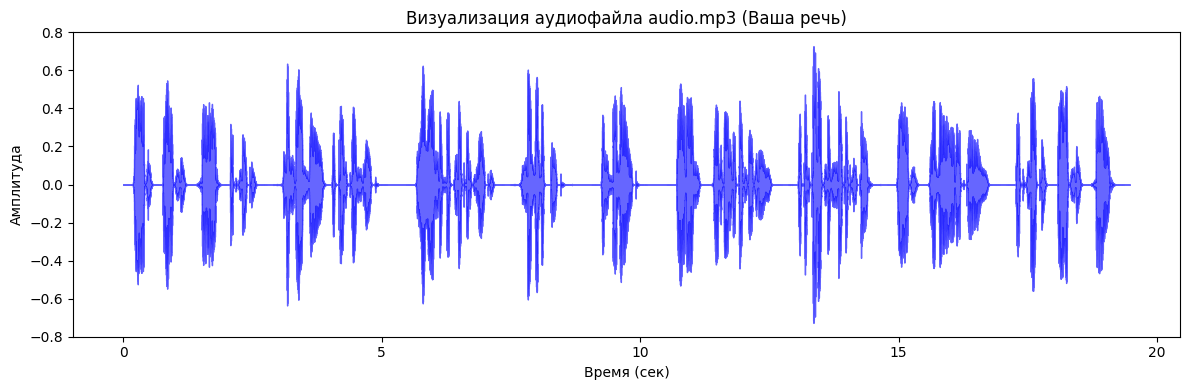

In [ ]:
# 6: Визуализация аудио и текста
# 6.1. Визуализация текста
display(HTML(f"""
<div style="background-color: #f0f8ff; padding: 15px; border-radius: 8px; border-left: 5px solid #007bff;">
    <h4>📊 Результат распознавания:</h4>
    <p style="font-size: 16px; font-family: monospace;">{recognized_text_raw}</p>
</div>
"""))

# 6.2. Визуализация аудиофайла (Waveform)
y, sr = librosa.load('audio.mp3', sr=None)
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, alpha=0.6, color='b')
plt.title('Визуализация аудиофайла audio.mp3 (Ваша речь)')
plt.xlabel('Время (сек)')
plt.ylabel('Амплитуда')
plt.tight_layout()
plt.show()

In [ ]:
# 7: Оценка качества с помощью метрики WER
# Вычисляем Word Error Rate (WER)
# text - это отформатированный исходный текст (эталон)
# recognized_text_formatted - это отформатированный распознанный текст
wer_score = jiwer.wer(text, recognized_text_formatted)

print("="*40)
print(f"📏 Эталонный текст (word count): {len(text.split())}")
print(f"📏 Распознанный текст (word count): {len(recognized_text_formatted.split())}")
print("-" * 40)
print(f"🎯 Значение метрики WER: {wer_score:.4f} ({wer_score*100:.2f}%)")
print("="*40)

if wer_score == 0:
    print("🏆 Идеальное распознавание! Ошибок нет.")
elif wer_score < 0.1:
    print("👍 Отличный результат распознавания.")
else:
    print("⚠️ Есть расхождения. Проверьте дикцию, фоновые шумы или формат текста.")

📏 Эталонный текст (word count): 21
📏 Распознанный текст (word count): 34
----------------------------------------
🎯 Значение метрики WER: 1.5714 (157.14%)
⚠️ Есть расхождения. Проверьте дикцию, фоновые шумы или формат текста.
